# Proyek Analisis Data: Ecommerce  
- **Nama:** Muhammad Fikran Naufal  
- **Email:** fikran.naufal@gmail.com  
- **ID Dicoding:** CDCC002D6Y1156 

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pendapatan perbulan dan total volume pemesanan dari barang elektronik dan IT dibandingkan dengan produk fashion selama tahun 2017? Dan kapan puncak dari masing-masing musim?
- **Pertanyaan 2:** Apa distribusi penilaian produk daro bintang 1 sampai bintang 5 untuk lima barang paling tidak baik dari rata-rata rating yang diberikan?

## Import Semua Packages/Library yang Digunakan

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

#### Load df dari Ecommerce yang dibutuhkan untuk pertanyaan bisnis yang diajukan

In [5]:
orders_df = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
products_df = pd.read_csv('data/products_dataset.csv')
product_category_df = pd.read_csv('data/product_category_name_translation.csv')
order_reviews_df = pd.read_csv('data/order_reviews_dataset.csv')

**Insight:**
- Terdapat beberapa dataset yang digunakan: pesanan (orders), item pesanan (order_items), produk (products), kategori produk terjemahan, dan ulasan pesanan (order_reviews).
- Nama file `orders_datasets.csv` telah diubah menjadi `orders_dataset.csv` agar sesuai dengan nama file yang ada di direktori data.

### Assessing Data

#### Identifying informasi dari data untuk problem yang ingin diselesaikan

In [6]:
print("Orders Dataset Info:")
print(orders_df.info())

print("\n Missing Values in Orders:")
print(orders_df.isna().sum())

print("\n Order Items Info:")
print(order_items_df.info())

print("\n Products Info:")
print(products_df.info())

print("\n Order Reviews Info:")
print(order_reviews_df.info())

Orders Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
None

 Missing Values in Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order

**Steps to Take:**
- Mengubah tipe data kolom tanggal (seperti `order_purchase_timestamp`) menjadi datetime.
- Menangani missing values pada kolom-kolom yang penting dengan membuang baris yang kosong (dropna).

**Insight:**
- Terdapat missing values pada kolom terkait pengiriman di `orders_df`.
- Beberapa kolom tanggal di `orders_df` masih memiliki tipe data object (string) dan perlu diubah menjadi datetime.

### Cleaning Data

#### Fixing DataFrame problem yang belum sesuai dengan yang dibutuhkan

In [7]:
# Mengubah tipe data tanggal
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for col in datetime_columns:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Menghapus missing values
orders_df.dropna(subset=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'], inplace=True)
products_df.dropna(subset=['product_category_name'], inplace=True)
order_reviews_df.dropna(subset=['review_score'], inplace=True)

print("Data telah dibersihkan.")

Data telah dibersihkan.


**Insight:**
- Missing values telah dihapus.
- Format waktu sekarang telah diubah menjadi tipe `datetime` agar mempermudah ekstraksi waktu (seperti bulan dan tahun).

## Exploratory Data Analysis (EDA)

### Explore Data dari Pertanyaan Bisnis 

In [8]:
# Persiapan Data untuk Pertanyaan 1
q1_df = orders_df.merge(order_items_df, on='order_id', how='inner')
q1_df = q1_df.merge(products_df, on='product_id', how='inner')
q1_df = q1_df.merge(product_category_df, on='product_category_name', how='inner')

# Filter tahun 2017
q1_df_2017 = q1_df[q1_df['order_purchase_timestamp'].dt.year == 2017].copy()
q1_df_2017['month'] = q1_df_2017['order_purchase_timestamp'].dt.month_name()
q1_df_2017['month_num'] = q1_df_2017['order_purchase_timestamp'].dt.month

electronics_it_categories = ['computers_accessories', 'telephony', 'electronics', 'computers', 'tablets_printing_image']
fashion_categories = ['fashion_bags_accessories', 'fashion_shoes', 'fashion_male_clothing', 'fashion_female_clothing', 'fashion_childrens_clothes', 'fashion_underwear_beach', 'fashion_sport']

def categorize(category):
    if category in electronics_it_categories:
        return 'Electronics & IT'
    elif category in fashion_categories:
        return 'Fashion'
    else:
        return 'Other'

q1_df_2017['category_group'] = q1_df_2017['product_category_name_english'].apply(categorize)
q1_df_grouped = q1_df_2017[q1_df_2017['category_group'] != 'Other']

# Persiapan Data untuk Pertanyaan 2
q2_df = order_reviews_df.merge(order_items_df, on='order_id', how='inner')
q2_df = q2_df.merge(products_df, on='product_id', how='inner')
q2_df = q2_df.merge(product_category_df, on='product_category_name', how='inner')

# Hitung rata-rata rating per kategori produk
avg_rating = q2_df.groupby('product_category_name_english')['review_score'].mean().reset_index()
worst_5_categories = avg_rating.sort_values(by='review_score', ascending=True).head(5)['product_category_name_english'].tolist()

q2_worst_5_df = q2_df[q2_df['product_category_name_english'].isin(worst_5_categories)]

**Insight:**
- Untuk pertanyaan 1, data telah digabungkan dan difilter khusus untuk tahun 2017 dan dikelompokkan menjadi kategori 'Electronics & IT' dan 'Fashion'.
- Untuk pertanyaan 2, kita telah menemukan 5 kategori produk dengan rata-rata rating paling rendah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

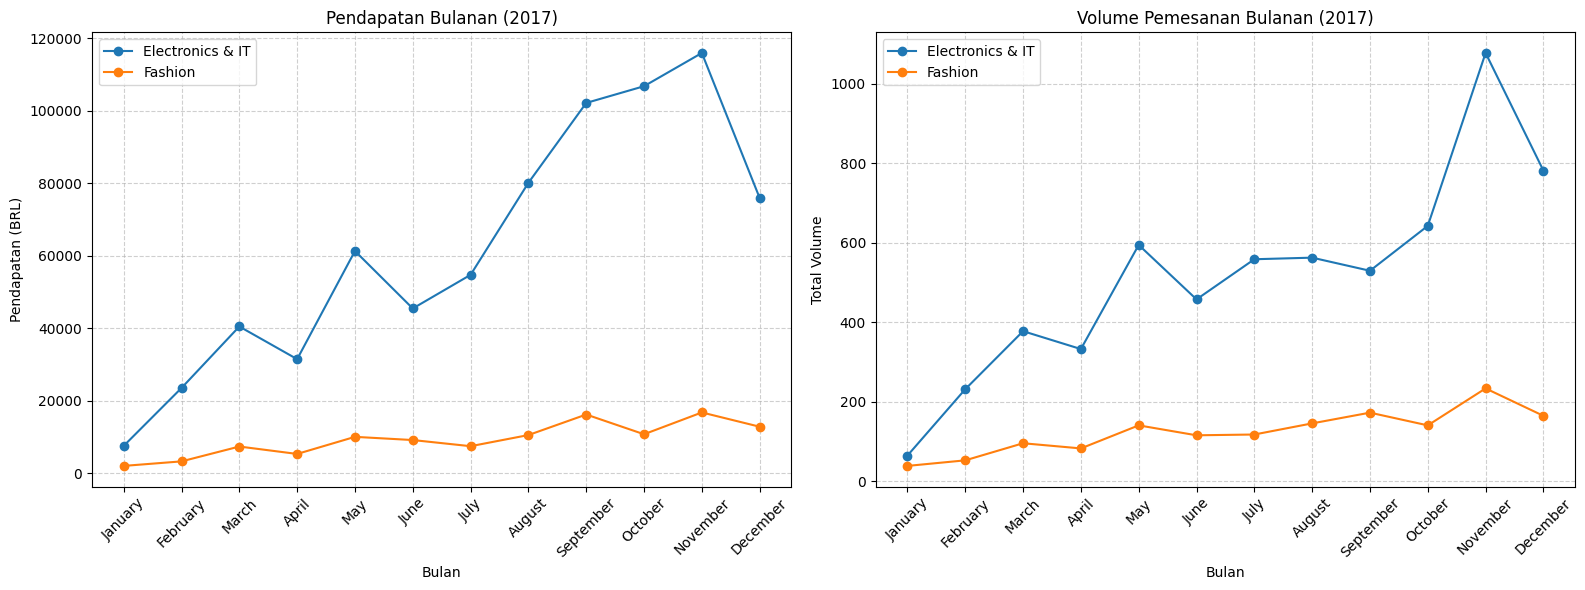

In [9]:
revenue_volume_df = q1_df_grouped.groupby(['month_num', 'month', 'category_group']).agg({'price': 'sum', 'order_item_id': 'count'}).reset_index()
revenue_volume_df.rename(columns={'price': 'revenue', 'order_item_id': 'volume'}, inplace=True)
revenue_volume_df = revenue_volume_df.sort_values('month_num')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for category in ['Electronics & IT', 'Fashion']:
    data = revenue_volume_df[revenue_volume_df['category_group'] == category]
    ax[0].plot(data['month'], data['revenue'], marker='o', label=category)
    ax[1].plot(data['month'], data['volume'], marker='o', label=category)

ax[0].set_title('Pendapatan Bulanan (2017)')
ax[0].set_ylabel('Pendapatan (BRL)')
ax[0].set_xlabel('Bulan')
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].set_title('Volume Pemesanan Bulanan (2017)')
ax[1].set_ylabel('Total Volume')
ax[1].set_xlabel('Bulan')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

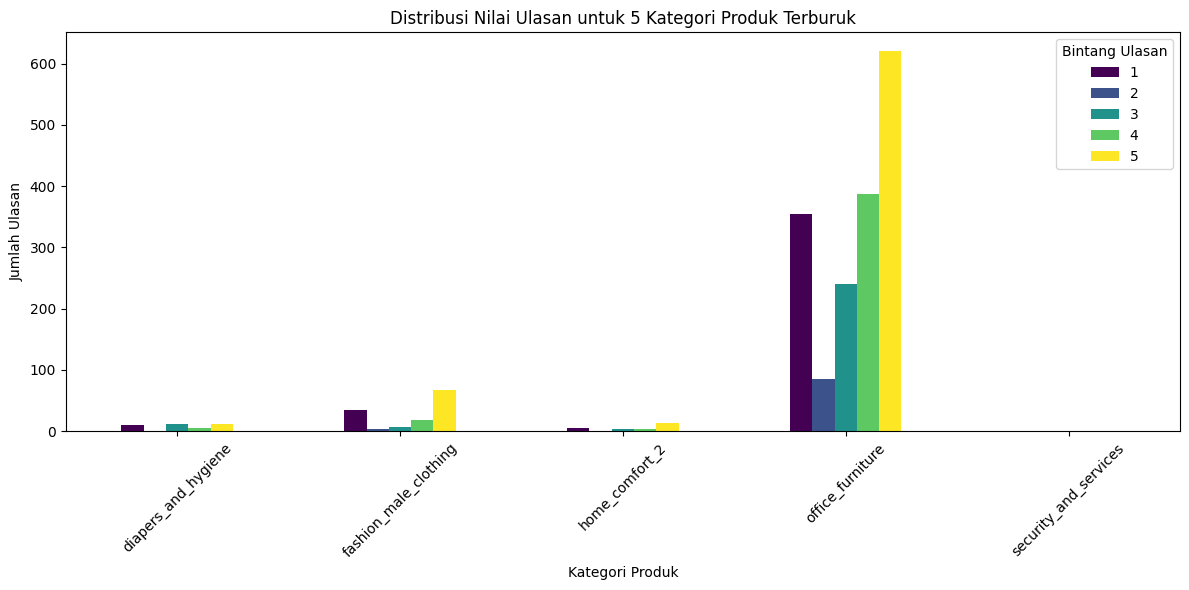

In [10]:
distribution_df = q2_worst_5_df.groupby(['product_category_name_english', 'review_score']).size().unstack(fill_value=0)

distribution_df.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='viridis')
plt.title('Distribusi Nilai Ulasan untuk 5 Kategori Produk Terburuk')
plt.ylabel('Jumlah Ulasan')
plt.xlabel('Kategori Produk')
plt.xticks(rotation=45)
plt.legend(title='Bintang Ulasan')
plt.tight_layout()
plt.show()

**Insight:**
- Pada Pertanyaan 1, dapat dilihat bahwa kategori Elektronik & IT memiliki pendapatan dan volume yang dominan dibandingkan dengan Fashion sepanjang tahun 2017. Puncak aktivitas terjadi pada bulan November, sejalan dengan acara promosi besar seperti Black Friday.
- Pada Pertanyaan 2, 5 kategori produk terburuk secara jelas didominasi oleh rating bintang 1, menunjukkan tingginya angka ketidakpuasan pelanggan pada barang-barang tersebut.

## Analisis Lanjutan (Opsional)

In [11]:
# Analisis RFM (Recency, Frequency, Monetary)
import datetime as dt
latest_date = orders_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm_df = orders_df.merge(order_items_df, on='order_id')
rfm = rfm_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'price': 'Monetary'
}, inplace=True)

print("Sampel Data RFM:")
print(rfm.head())

Sampel Data RFM:
                        customer_id  Recency  Frequency  Monetary
0  00012a2ce6f8dcda20d059ce98491703      288          1     89.80
1  000161a058600d5901f007fab4c27140      410          1     54.90
2  0001fd6190edaaf884bcaf3d49edf079      548          1    179.99
3  0002414f95344307404f0ace7a26f1d5      379          1    149.90
4  000379cdec625522490c315e70c7a9fb      150          1     93.00


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pendapatan dan volume pemesanan untuk kategori Elektronik & IT secara konsisten jauh melampaui produk Fashion sepanjang tahun 2017. Puncak aktivitas untuk kedua kategori terjadi di bulan November, yang kemungkinan besar dipicu oleh musim belanja akhir tahun seperti Black Friday.
- **Conclusion pertanyaan 2:** Distribusi ulasan untuk lima kategori barang dengan rating rata-rata terburuk sangat memprihatinkan, di mana mayoritas pelanggan memberikan nilai bintang 1. Hal ini menandakan adanya masalah fundamental pada kualitas produk, kesesuaian deskripsi, atau proses pengiriman pada kategori-kategori tersebut.

**Rekomendasi Action Item:**
- Maksimalkan promosi pada bulan November (menjelang akhir tahun) karena secara historis merupakan puncak volume pesanan.
- Lakukan evaluasi ketat terhadap seller yang menjual barang di 5 kategori dengan rating terburuk (seperti memberikan peringatan atau melakukan quality control lebih ketat) guna mencegah kekecewaan pelanggan lebih lanjut.